In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (8,6)
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.grid.which'] = 'both'
mpl.rcParams['grid.color'] = 'grey'
mpl.rcParams['grid.alpha'] = 0.2
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 22
mpl.rcParams['legend.handlelength'] = 3
mpl.rcParams['legend.fontsize'] = 20
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True      # show ticks on the top axis
mpl.rcParams['ytick.right'] = True    # show ticks on the right axis

from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

In [2]:
folder_stellar_mass = '../injection_sampler_v2/'

bbh_events = h5py.File(folder_stellar_mass + 'pop_m_FP4_spin_custom_fref_5.0_z_MD_lmr_130_BBH_34K_samples_v2.h5', 'r')
nsbh_events = h5py.File(folder_stellar_mass + 'pop_m_FP4_spin_AGU_fref_5.0_z_MD_lmr_130_NSBH_43K_samples_v2.h5', 'r')
bns_events = h5py.File(folder_stellar_mass + 'pop_m_FP4_spin_NS_fref_5.0_z_MD_lmr_130_BNS_109K_samples_v2.h5', 'r')

folder_exotic = '../../'

pbhs_events = h5py.File(folder_exotic + 'pbh/PBH_cat_1yr.h5', 'r')
imbh_events = h5py.File(folder_exotic + 'imbhs/IMBH_cat_1yr.h5', 'r')
pop3_events = h5py.File(folder_exotic + 'pop3/POPIII_cat_1yr_fiducial.h5', 'r')

figure_folder = 'figures/'

In [3]:
print('Number of BBH events:', len(bbh_events['mass_1_source']))
print('Number of NSBH events:', len(nsbh_events['mass_1_source']))
print('Number of BNS events:', len(bns_events['mass_1_source']))

Number of BBH events: 34166
Number of NSBH events: 43925
Number of BNS events: 109267


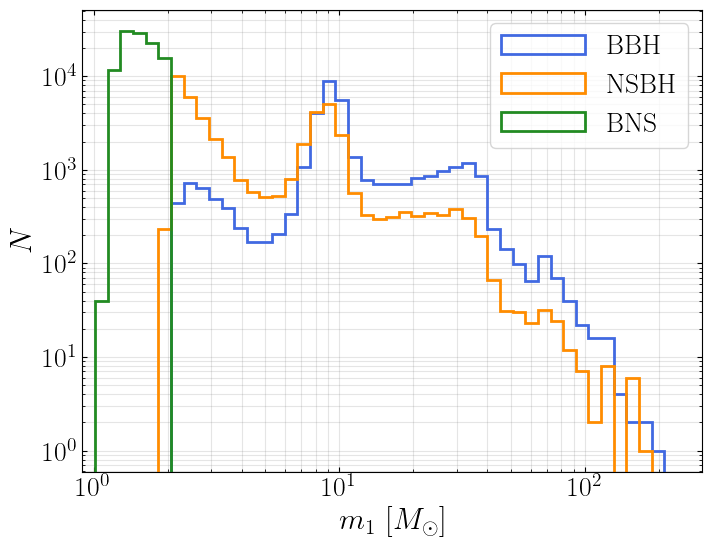

In [4]:
bins = np.logspace(np.log10(0.9), np.log10(300), 50)

density = False
lw = 2

plt.hist(bbh_events['mass_1_source'], bins=bins, density=density, histtype='step', label='BBH', color='royalblue', linewidth=lw)
plt.hist(nsbh_events['mass_1_source'], bins=bins, density=density, histtype='step', label='NSBH', color='darkorange', linewidth=lw)
plt.hist(bns_events['mass_1_source'], bins=bins, density=density, histtype='step', label='BNS', color='forestgreen', linewidth=lw)
total_events = np.concatenate([bbh_events['mass_1_source'], nsbh_events['mass_1_source'], bns_events['mass_1_source']])
#plt.hist(total_events, bins=bins, density=density, histtype='step', label='Total', color='black', linestyle='--', linewidth=lw)

plt.loglog()
plt.xlim(0.9, 300)
plt.xlabel(r'$m_1$ [$M_\odot$]')
plt.ylabel(r'$N$')
#plt.ylabel(r'PDF')
plt.legend()

plt.savefig(figure_folder + 'mass_1_source_histogram.pdf', bbox_inches='tight')
plt.show()

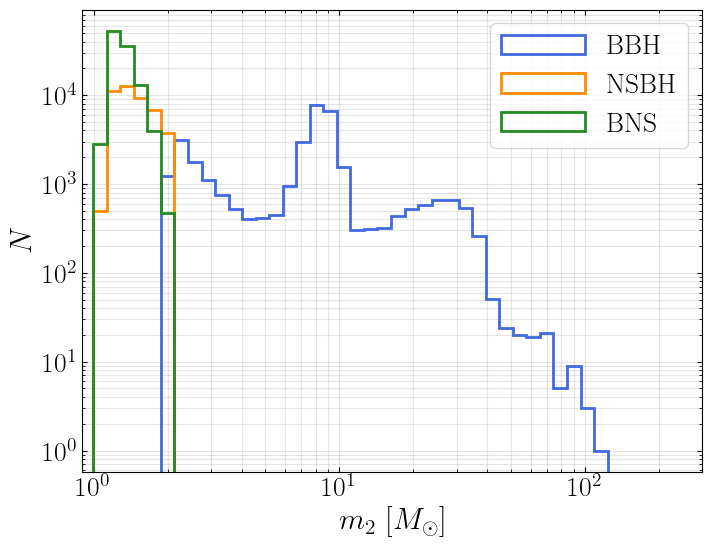

In [5]:
bins = np.logspace(np.log10(0.6), np.log10(300), 50)

density = False
lw = 2

plt.hist(bbh_events['mass_2_source'], bins=bins, density=density, histtype='step', label='BBH', color='royalblue', linewidth=lw)
plt.hist(nsbh_events['mass_2_source'], bins=bins, density=density, histtype='step', label='NSBH', color='darkorange', linewidth=lw)
plt.hist(bns_events['mass_2_source'], bins=bins, density=density, histtype='step', label='BNS', color='forestgreen', linewidth=lw)
total_events = np.concatenate([bbh_events['mass_2_source'], nsbh_events['mass_2_source'], bns_events['mass_2_source']])
#plt.hist(total_events, bins=bins, density=density, histtype='step', label='Total', color='black', linestyle='--', linewidth=lw)

plt.loglog()
plt.xlim(0.9, 300)
plt.xlabel(r'$m_2$ [$M_\odot$]')
plt.ylabel(r'$N$')
#plt.ylabel(r'PDF')
plt.legend()

plt.savefig(figure_folder + 'mass_2_source_histogram.pdf', bbox_inches='tight')
plt.show()

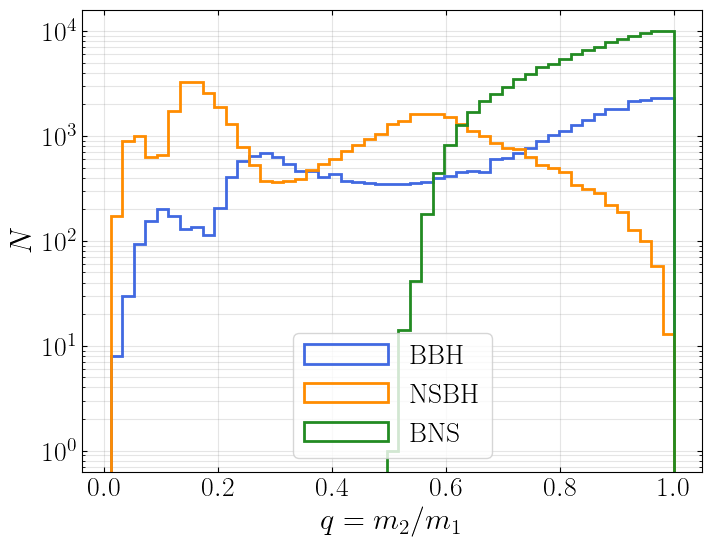

In [6]:
#bins = np.logspace(np.log10(0.6), np.log10(300), 50)
bins = np.linspace(np.min(bbh_events['mass_2_source'][:]/bbh_events['mass_1_source'][:]), 1, 50)

density = False
lw = 2

plt.hist(bbh_events['mass_2_source'][:]/bbh_events['mass_1_source'][:], bins=bins, density=density, histtype='step', label='BBH', color='royalblue', linewidth=lw)
plt.hist(nsbh_events['mass_2_source'][:]/nsbh_events['mass_1_source'][:], bins=bins, density=density, histtype='step', label='NSBH', color='darkorange', linewidth=lw)
plt.hist(bns_events['mass_2_source'][:]/bns_events['mass_1_source'][:], bins=bins, density=density, histtype='step', label='BNS', color='forestgreen', linewidth=lw)

plt.yscale('log')
#plt.xlim(0.1, 1)
plt.xlabel(r'$q = m_2 / m_1$')
plt.ylabel(r'$N$')
#plt.ylabel(r'PDF')
plt.legend()

plt.savefig(figure_folder + 'mass_ratio_histogram.pdf', bbox_inches='tight')
plt.show()

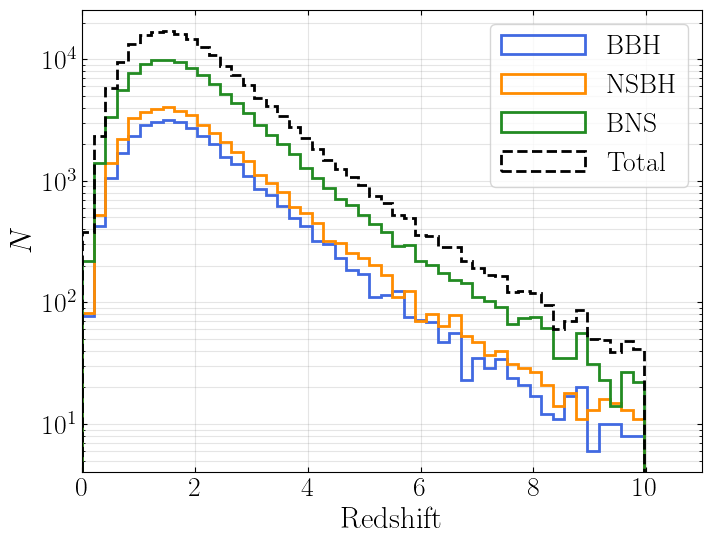

In [7]:
#bins = np.logspace(np.log10(np.min(bbh_events['redshift'][:])), np.log10(np.max(bbh_events['redshift'][:])), 50)
bins = np.linspace(0., np.max(bbh_events['redshift'][:]), 50)

density = False
lw = 2

plt.hist(bbh_events['redshift'][:], bins=bins, density=density, histtype='step', label='BBH', color='royalblue', linewidth=lw)
plt.hist(nsbh_events['redshift'][:], bins=bins, density=density, histtype='step', label='NSBH', color='darkorange', linewidth=lw)
plt.hist(bns_events['redshift'][:], bins=bins, density=density, histtype='step', label='BNS', color='forestgreen', linewidth=lw)
total_events = np.concatenate([bbh_events['redshift'][:], nsbh_events['redshift'][:], bns_events['redshift'][:]])
plt.hist(total_events, bins=bins, density=density, histtype='step', label='Total', color='black', linestyle='--', linewidth=lw)

plt.yscale('log')
plt.xlim(0., 11)
plt.xlabel('Redshift')
plt.ylabel(r'$N$')
#plt.ylabel(r'PDF')
plt.legend()

plt.savefig(figure_folder + 'redshift_histogram.pdf', bbox_inches='tight')
plt.show()

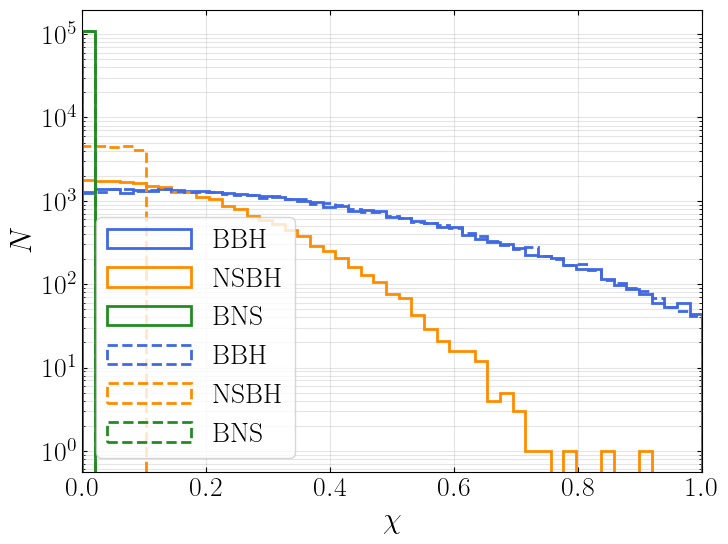

In [8]:
#bins = np.logspace(np.log10(0.6), np.log10(300), 50)
bins = np.linspace(0, 1, 50)

density = False
lw = 2

plt.hist(bbh_events['a_1'][:], bins=bins, density=density, histtype='step', label='BBH', color='royalblue', linewidth=lw)
plt.hist(nsbh_events['chi_1'][:], bins=bins, density=density, histtype='step', label='NSBH', color='darkorange', linewidth=lw)
plt.hist(bns_events['chi_1'][:], bins=bins, density=density, histtype='step', label='BNS', color='forestgreen', linewidth=lw)
plt.hist(bbh_events['a_2'][:], bins=bins, density=density, histtype='step', label='BBH', color='royalblue', linewidth=lw, linestyle='--')
plt.hist(nsbh_events['chi_2'][:], bins=bins, density=density, histtype='step', label='NSBH', color='darkorange', linewidth=lw, linestyle='--')
plt.hist(bns_events['chi_2'][:], bins=bins, density=density, histtype='step', label='BNS', color='forestgreen', linewidth=lw, linestyle='--')

plt.yscale('log')
plt.xlim(0, 1)
plt.xlabel(r'$\chi$')
plt.ylabel(r'$N$')
#plt.ylabel(r'PDF')
plt.legend()

plt.savefig(figure_folder + 'spin_histogram.pdf', bbox_inches='tight')
plt.show()

## Exotic

In [9]:
print('Number of PBH events:', len(pbhs_events['m1_src']))
print('Number of IMBH events:', len(imbh_events['m1_src']))
print('Number of POPIII events:', len(pop3_events['m1_src']))

Number of PBH events: 600
Number of IMBH events: 3985
Number of POPIII events: 5470


In [10]:
pbhs_events.keys()

<KeysViewHDF5 ['Mc', 'Phicoal', 'chi1z', 'chi2z', 'dL', 'dec', 'eta', 'm1_src', 'm2_src', 'phi', 'psi', 'ra', 'tcoal', 'theta', 'thetaJN', 'z']>

### PBHs

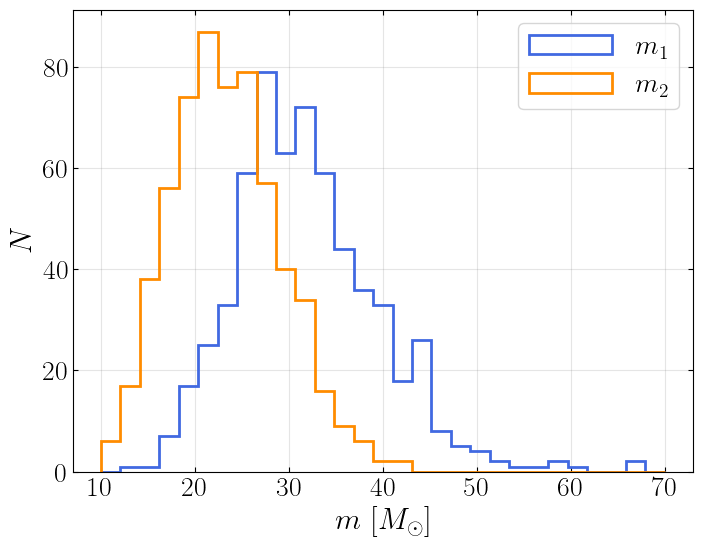

In [17]:
bins = np.linspace(10, 70, 30)

density = False
lw = 2

plt.hist(pbhs_events['m1_src'], bins=bins, density=density, histtype='step', label=r'$m_1$', color='royalblue', linewidth=lw)
plt.hist(pbhs_events['m2_src'], bins=bins, density=density, histtype='step', label=r'$m_2$', color='darkorange', linewidth=lw)


#plt.loglog()
#plt.xlim(0.9, 300)
plt.xlabel(r'$m$ [$M_\odot$]')
plt.ylabel(r'$N$')
#plt.ylabel(r'PDF')
plt.legend()

plt.savefig(figure_folder + 'mass_pbh_source_histogram.pdf', bbox_inches='tight')
plt.show()

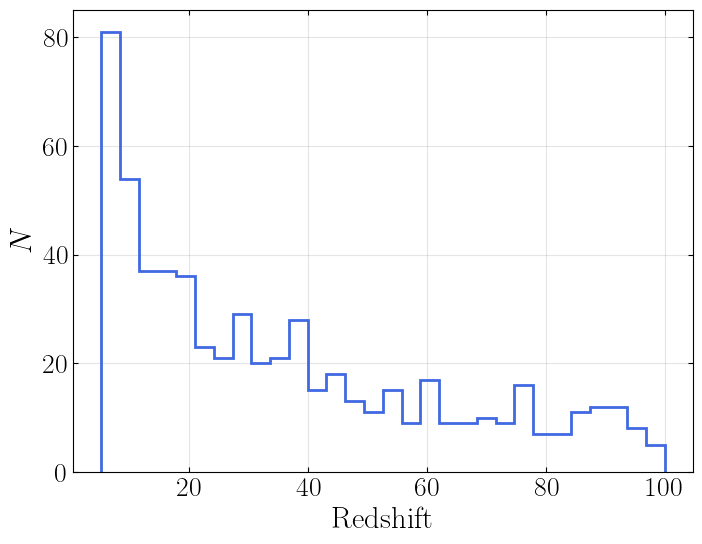

In [26]:
#bins = np.logspace(np.log10(0.9), np.log10(300), 50)
bins = 30

density = False
lw = 2

plt.hist(pbhs_events['z'], bins=bins, density=density, histtype='step', color='royalblue', linewidth=lw)

#plt.loglog()
#plt.xlim(0.9, 300)
plt.xlabel(r'Redshift')
plt.ylabel(r'$N$')
#plt.ylabel(r'PDF')
#plt.legend()

plt.savefig(figure_folder + 'redshift_pbh_histogram.pdf', bbox_inches='tight')
plt.show()

### IMBHs

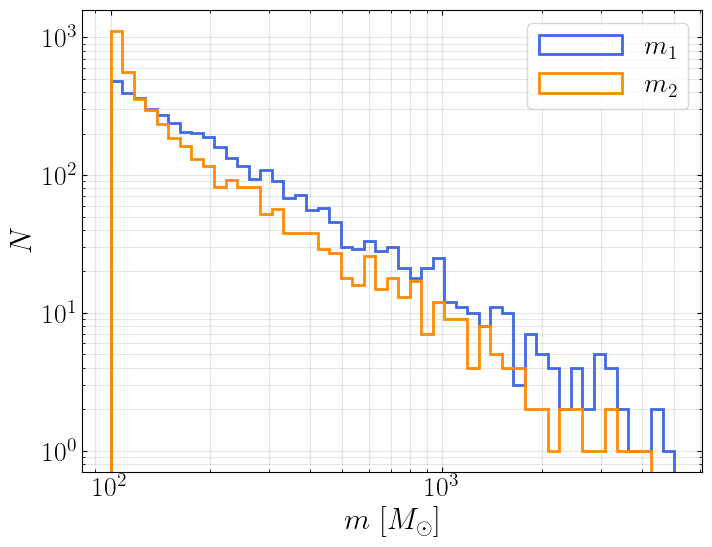

In [19]:
bins = np.logspace(np.log10(100), np.log10(5000), 50)

density = False
lw = 2

plt.hist(imbh_events['m1_src'], bins=bins, density=density, histtype='step', label=r'$m_1$', color='royalblue', linewidth=lw)
plt.hist(imbh_events['m2_src'], bins=bins, density=density, histtype='step', label=r'$m_2$', color='darkorange', linewidth=lw)

plt.loglog()
#plt.xlim(0.9, 300)
plt.xlabel(r'$m$ [$M_\odot$]')
plt.ylabel(r'$N$')
#plt.ylabel(r'PDF')
plt.legend()

plt.savefig(figure_folder + 'mass_imbh_source_histogram.pdf', bbox_inches='tight')
plt.show()


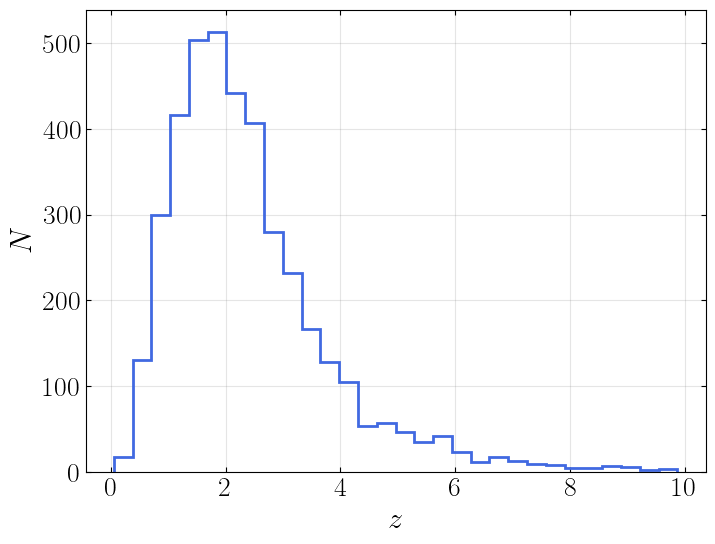

In [20]:
#bins = np.logspace(np.log10(0.9), np.log10(300), 50)
bins = 30

density = False
lw = 2

plt.hist(imbh_events['z'], bins=bins, density=density, histtype='step', color='royalblue', linewidth=lw)

#plt.loglog()
#plt.xlim(0.9, 300)
plt.xlabel(r'$z$')
#plt.ylabel(r'PDF')
plt.ylabel(r'$N$')
#plt.legend()

plt.savefig(figure_folder + 'redshift_imbh_histogram.pdf', bbox_inches='tight')
plt.show()


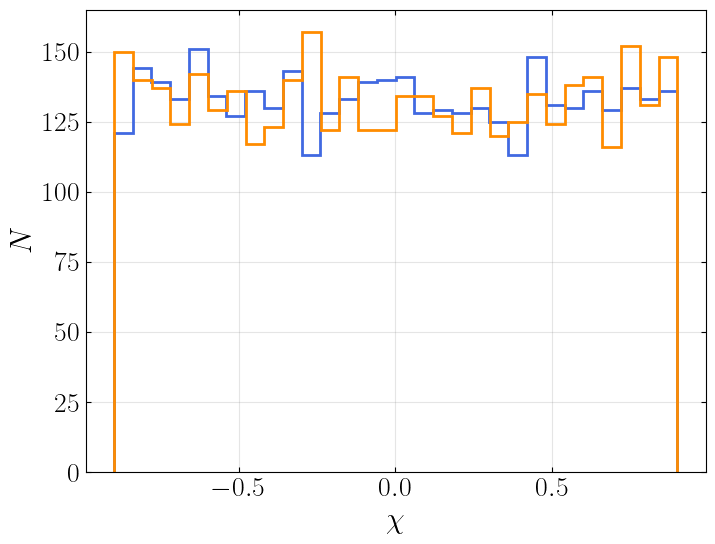

In [29]:
#bins = np.logspace(np.log10(0.9), np.log10(300), 50)
bins = 30

density = False
lw = 2

plt.hist(imbh_events['chi1z'], bins=bins, density=density, histtype='step', color='royalblue', linewidth=lw)
plt.hist(imbh_events['chi2z'], bins=bins, density=density, histtype='step', color='darkorange', linewidth=lw)

#plt.loglog()
#plt.xlim(0.9, 300)
plt.xlabel(r'$\chi$')
#plt.ylabel(r'PDF')
plt.ylabel(r'$N$')
#plt.legend()

plt.savefig(figure_folder + 'spin_imbh_histogram.pdf', bbox_inches='tight')
plt.show()

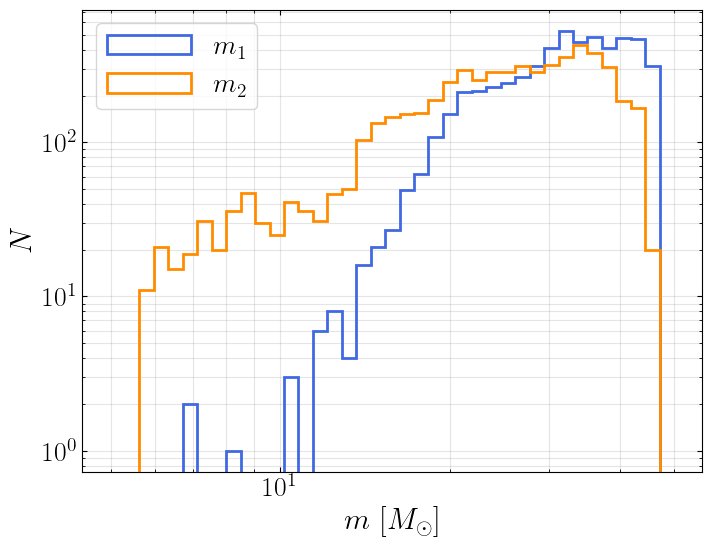

In [23]:
bins = np.logspace(np.log10(5), np.log10(50), 40)

density = False
lw = 2

plt.hist(pop3_events['m1_src'], bins=bins, density=density, histtype='step', label=r'$m_1$', color='royalblue', linewidth=lw)
plt.hist(pop3_events['m2_src'], bins=bins, density=density, histtype='step', label=r'$m_2$', color='darkorange', linewidth=lw)

plt.loglog()
#plt.xlim(0.9, 300)
plt.xlabel(r'$m$ [$M_\odot$]')
plt.ylabel(r'$N$')
#plt.ylabel(r'PDF')
plt.legend()

plt.savefig(figure_folder + 'mass_pop3_source_histogram.pdf', bbox_inches='tight')
plt.show()

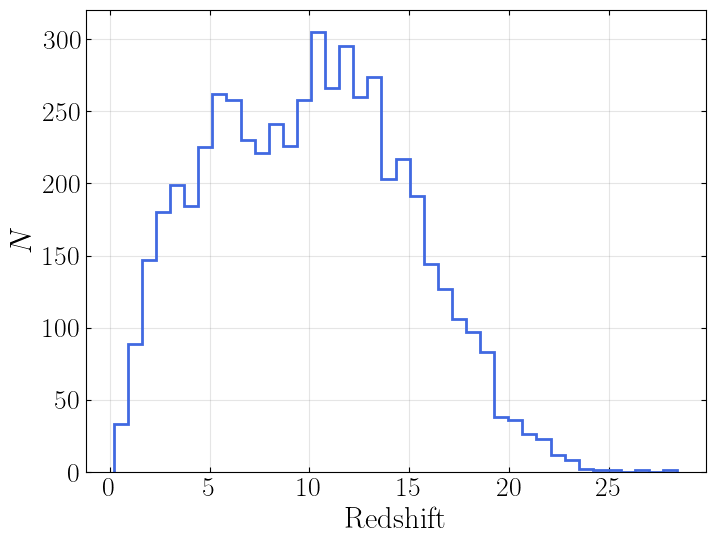

In [30]:
#bins = np.logspace(np.log10(0.9), np.log10(300), 50)
bins = 40

density = False
lw = 2

plt.hist(pop3_events['z'], bins=bins, density=density, histtype='step', color='royalblue', linewidth=lw)

#plt.loglog()
#plt.xlim(0.9, 300)
plt.xlabel(r'Redshift')
plt.ylabel(r'$N$')
#plt.ylabel(r'PDF')
#plt.legend()

plt.savefig(figure_folder + 'redshift_pop3_histogram.pdf', bbox_inches='tight')
plt.show()